In [8]:
import pandas as pd
import seaborn as sns
import re
import matplotlib.pyplot as plt
import os
from matplotlib.patches import Patch
import copy

def split_patches(patches, n, group_size):
    patches_groups = [patches[i * group_size:(i + 1) * group_size] for i in range(n)]    
    baseline_group = patches_groups[0]
    
    return (patches_groups, baseline_group)

def create_speedup_message(patches_groups, baseline_group):
    messages = []
    for pid, p in enumerate(baseline_group):
        baseline_height = baseline_group[pid].get_height()
        message = []
        for group in patches_groups[1:]:
            if group[pid].get_height() > 0:
                speedup = baseline_height / group[pid].get_height()
                message.append(f'{speedup:.1f}x')
        messages.append("/".join(message))
    return messages

# Load the csv files for NES and Apache Flink
df = pd.read_csv("statistic_store_benchmark.csv")

# Splitting BM_InsertStatistic and BM_GetStatistics
cols_insert = ['storeType', 'windowSize', 'numStatisticIds', 'numThreads', 'numStatistics', 'statisticSize']
cols_get = ['storeType', 'windowSize', 'numStatisticIds', 'pctAccessExisting', 'numStatistics', 'statisticSize','numThreads']
mask_insert = df['name'].str.startswith('BM_InsertStatistic')
mask_get = df['name'].str.startswith('BM_GetStatistics')
df.loc[mask_insert, cols_insert] = df.loc[mask_insert, 'name'].str.split('/', expand=True).iloc[:, 1:7].astype(int).values
df.loc[mask_get, cols_get] = df.loc[mask_get, 'name'].str.split('/', expand=True).iloc[:, 1:8].astype(int).values
df['name'] = df['name'].str.split('/').str[0]

# Mapping store type
store_type_map = {0: 'DEFAULT', 1: 'WINDOW', 2: 'SUB_STORES'}
df['storeType'] = df['storeType'].astype(int).map(store_type_map)

# Create directory if it doesn't exist
output_dir = 'statistic_stores'
os.makedirs(output_dir, exist_ok=True)

df

,name,iterations,real_time,cpu_time,time_unit,bytes_per_second,items_per_second,label,error_occurred,error_message,storeType,windowSize,numStatisticIds,numThreads,numStatistics,statisticSize,pctAccessExisting
0,BM_InsertStatistic,18387290,38.6070,38.6004,ns,NaN,25906500.0,DEFAULT,NaN,NaN,DEFAULT,10.0,1.0,1.0,100.0,1024.0,NaN
1,BM_InsertStatistic,26337848,23.8420,23.8333,ns,NaN,41958100.0,DEFAULT,NaN,NaN,DEFAULT,10.0,10.0,1.0,100.0,1024.0,NaN
2,BM_InsertStatistic,13728200,50.3465,50.3461,ns,NaN,19862500.0,DEFAULT,NaN,NaN,DEFAULT,10.0,10.0,1.0,1000.0,1024.0,NaN
3,BM_InsertStatistic,415862,1674.6600,1674.5500,ns,NaN,597176.0,DEFAULT,NaN,NaN,DEFAULT,10.0,10.0,1.0,100.0,102400.0,NaN
4,BM_InsertStatistic,18971679,38.0725,38.0648,ns,NaN,26271000.0,DEFAULT,NaN,NaN,DEFAULT,100.0,1.0,1.0,100.0,1024.0,NaN
5,BM_InsertStatistic,26366530,23.5771,23.5698,ns,NaN,42427200.0,DEFAULT,NaN,NaN,DEFAULT,100.0,10.0,1.0,100.0,1024.0,NaN
6,BM_InsertStatistic,19031047,38.0533,38.0404,ns,NaN,26287900.0,DEFAULT,NaN,NaN,DEFAULT,1000.0,1.0,1.0,100.0,1024.0,NaN
7,BM_InsertStatistic,26190148,23.5865,23.5811,ns,NaN,42406900.0,DEFAULT,NaN,NaN,DEFAULT,1000.0,10.0,1.0,100.0,1024.0,NaN
8,BM_InsertStatistic,2498751,213.6240,213.6090,ns,NaN,4681450.0,WINDOW,NaN,NaN,WINDOW,10.0,1.0,1.0,100.0,1024.0,NaN
9,BM_InsertStatistic,2612376,218.0390,217.9450,ns,NaN,4588310.0,WINDOW,NaN,NaN,WINDOW,10.0,10.0,1.0,100.0,1024.0,NaN


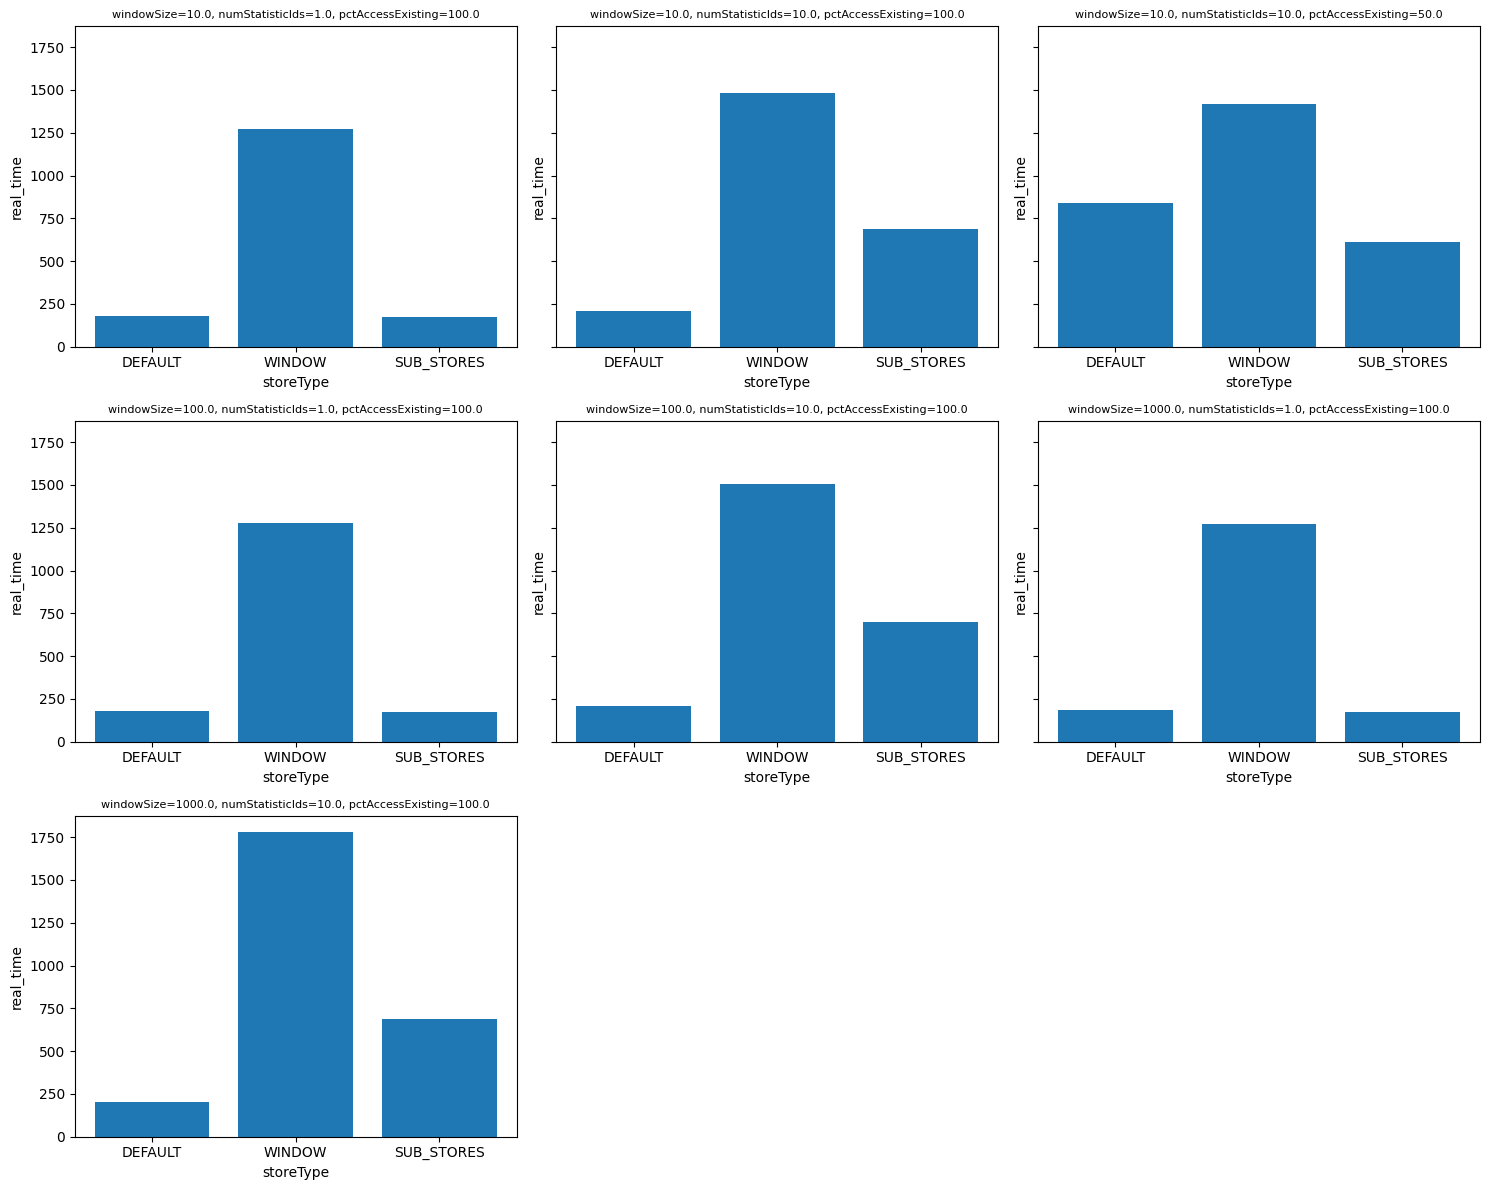

In [10]:
df_get = df[df['name'] == 'BM_GetStatistics'].copy()

# identify varying parameters (excluding storeType which is the x-axis)
params = ['windowSize', 'numStatisticIds', 'pctAccessExisting', 'numStatistics', 'statisticSize', 'numThreads']
varying = [p for p in params if df_get[p].nunique() > 1]

# create a label column for each unique parameter combination
df_get['params'] = df_get[varying].astype(str).agg(', '.join, axis=1)

combos = df_get[varying].drop_duplicates().reset_index(drop=True)
n = len(combos)
ncols = min(3, n)
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False, sharey=True)

for idx, (_, row) in enumerate(combos.iterrows()):
  ax = axes[idx // ncols][idx % ncols]
  mask = (df_get[varying] == row[varying]).all(axis=1)
  subset = df_get[mask]
  ax.bar(subset['storeType'], subset['real_time'])
  ax.set_xlabel('storeType')
  ax.set_ylabel('real_time')
  title = ', '.join(f'{k}={row[k]}' for k in varying)
  ax.set_title(title, fontsize=8)

# hide unused axes
for idx in range(n, nrows * ncols):
  axes[idx // ncols][idx % ncols].set_visible(False)

plt.tight_layout()
plt.show()